## Titanic Survival Prediction using Logistic Regression

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Load Dataset

In [2]:
df = pd.read_csv("titanic.csv")

## View Dataset 

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

In [7]:
# Missing values

df["Age"] = df["Age"].fillna(df["Age"].median())

df.drop("Cabin", axis=1, inplace=True)

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [8]:
# Droping unnecessary columns

df.drop(columns=["PassengerId","Name","Ticket"], axis=1, inplace=True)

## Data Preprocessing

In [9]:
# Label Encoding

le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

In [10]:
# One-Hot Encoding

df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


## Train-Test Split

In [12]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Scaling

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Model Training

In [15]:
model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Prediction

In [16]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

## Model Evaluation

In [21]:
# Metrics Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8101
Precision : 0.7857
Recall : 0.7432
F1 Score : 0.7639


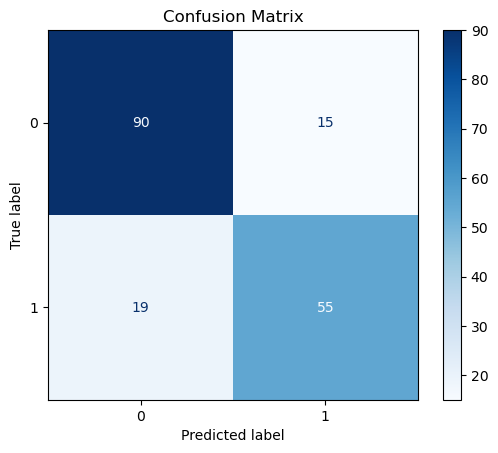

In [18]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [19]:
# Classification Report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Feature Coefficient

In [20]:
coefficient = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
})

coefficient.sort_values(by="Coefficient")

,Feature,Coefficient
1,Sex,-1.277104
0,Pclass,-0.785328
2,Age,-0.396152
3,SibSp,-0.349952
7,Embarked_S,-0.189423
4,Parch,-0.096142
6,Embarked_Q,-0.046058
5,Fare,0.126511


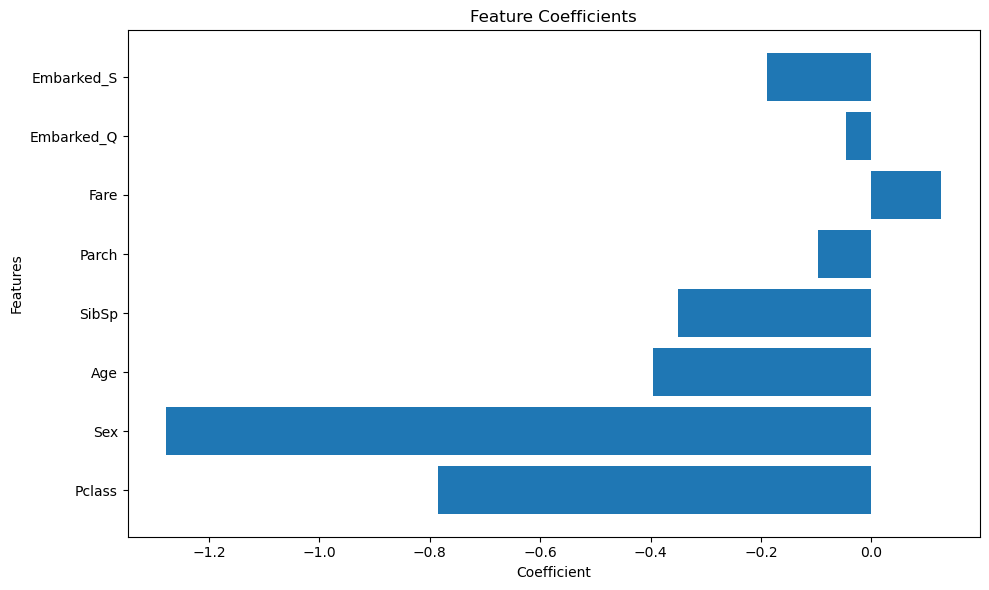

In [55]:
plt.figure(figsize=(10,6))

plt.barh(
    coefficient["Feature"],
    coefficient["Coefficient"],
)

plt.title("Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## Conclusion

In this project, a **Logistic Regression** model was built to predict passenger survival on the Titanic dataset. After preprocessing the data and training the model, it achieved an **accuracy of 81%**, correctly predicting most passenger outcomes.

The classification report shows that the model performed slightly better at predicting passengers who **did not survive (Class 0)**, achieving a **precision of 83%**, **recall of 86%**, and an **F1-score of 84%**. For passengers who **survived (Class 1)**, the model achieved a **precision of 79%**, **recall of 74%**, and an **F1-score of 76%**.

Overall, the model provides a good baseline for this binary classification problem. While there is room for improvement, especially in identifying survivors, the results demonstrate that Logistic Regression can effectively classify Titanic passenger survival using the selected features.